# Movie Recommendation System - preprocessing pipeline

Этот ноутбук реализует полный пайплайн предобработки датасета фильмов: от сырых данных до готовой модели рекомендаций на основе TF-IDF.

---

## 1.0 Data load

Загружаем датасет и сразу убираем лишние колонки (например, `Wiki Page`), которые не несут смысловой нагрузки для модели.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load the dataset
# the file name must match your local file
df = pd.read_csv('movie dataset.csv')

# drop unnecessary columns immediately
if 'Wiki Page' in df.columns:
    df.drop(columns=['Wiki Page'], inplace=True)

# raw data
print("Data Loaded.")
df.head()

Data Loaded.


,Release Year,Title,Origin/Ethnicity,Director,Cast,Genre,Plot
0,1901,Kansas Saloon Smashers,American,Unknown,NaN,unknown,"A bartender is working at a saloon, serving dr..."
1,1901,Love by the Light of the Moon,American,Unknown,NaN,unknown,"The moon, painted with a smiling face hangs ov..."
2,1901,The Martyred Presidents,American,Unknown,NaN,unknown,"The film, just over a minute long, is composed..."
3,1901,"Terrible Teddy, the Grizzly King",American,Unknown,NaN,unknown,Lasting just 61 seconds and consisting of two ...
4,1902,Jack and the Beanstalk,American,"George S. Fleming, Edwin S. Porter",NaN,unknown,The earliest known adaptation of the classic f...


## 1.1 Data cleaning

Базовая чистка данных перед анализом:

- Убираем строки с жанром `'unknown'`, они не дают никакой информации для рекомендаций.
- Заполняем пропуски в ключевых колонках (`Cast`, `Director`, `Genre`, `Plot`) значением `'Unknown'`, чтобы не получить ошибки на следующих шагах.

In [4]:
# filter out 'unknown' genres
df_clean = df[df['Genre'] != 'unknown'].copy()

# fill missing metadata with 'Unknown' to prevent errors
cols_to_fill = ['Cast', 'Director', 'Genre', 'Plot']
for col in cols_to_fill:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('Unknown')

# stats
print(f"Original shape: {df.shape}")
print(f"Cleaned shape:  {df_clean.shape}")
print(f"Dropped {len(df) - len(df_clean)} rows of bad data.")

Original shape: (34886, 7)
Cleaned shape:  (28803, 7)
Dropped 6083 rows of bad data.


## 2.0 EDA — Exploratory Data Analysis

Визуальный разведочный анализ данных. Смотрим на распределения жанров, режиссёров, происхождения фильмов и временные тренды чтобы понять, с каким датасетом мы работаем, прежде чем строить модель.

### 2.1 Жанры и режиссёры

Топ-10 жанров по количеству фильмов и топ-10 режиссёров в датасете.

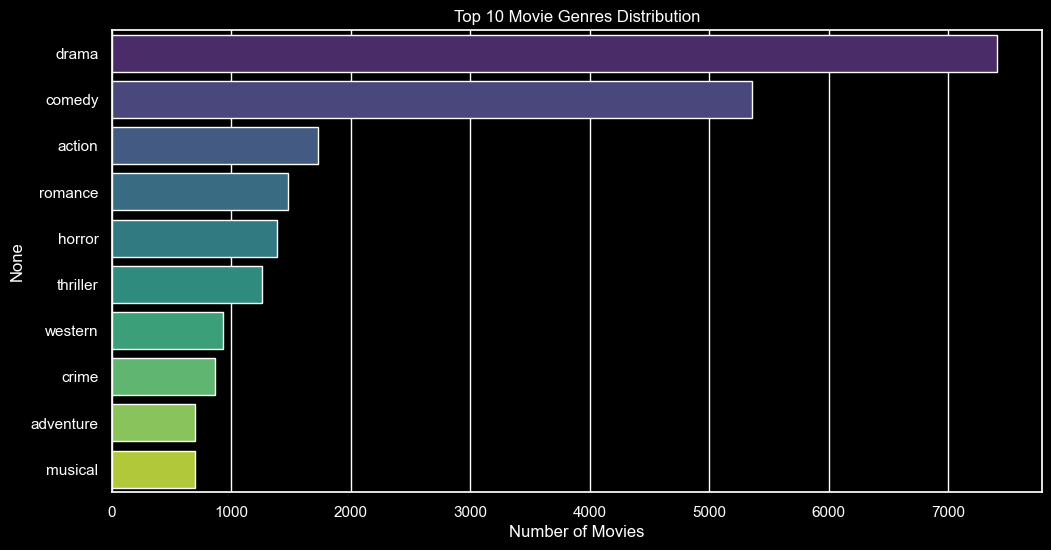

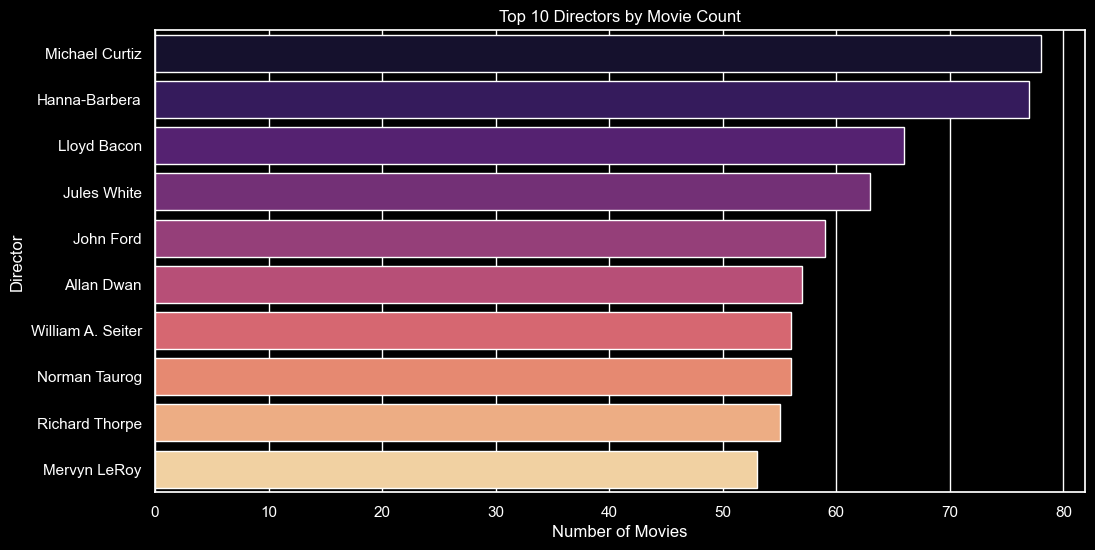

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# style
sns.set_theme(style="darkgrid")
plt.style.use('dark_background')

# 1: top 10 genre
plt.figure(figsize=(12, 6))

all_genres = df_clean['Genre'].str.split(', ', expand=True).stack()
top_genres = all_genres.value_counts().head(10)

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    legend=False,
    palette="viridis" 
)

plt.title('Top 10 Movie Genres Distribution')
plt.xlabel('Number of Movies')
plt.show()


# 2: top 10 directors
plt.figure(figsize=(12, 6))

top_directors = df_clean['Director'].value_counts().head(11)
top_directors = top_directors[top_directors.index != 'Unknown']

sns.barplot(
    x=top_directors.values,
    y=top_directors.index,
    hue=top_directors.index,
    legend=False,
    palette="magma" 
)

plt.title('Top 10 Directors by Movie Count')
plt.xlabel('Number of Movies')
plt.show()

### 2.2 Происхождение / этническая принадлежность

Распределение фильмов по стране или этнической принадлежности производства. Помогает понять географический охват датасета.

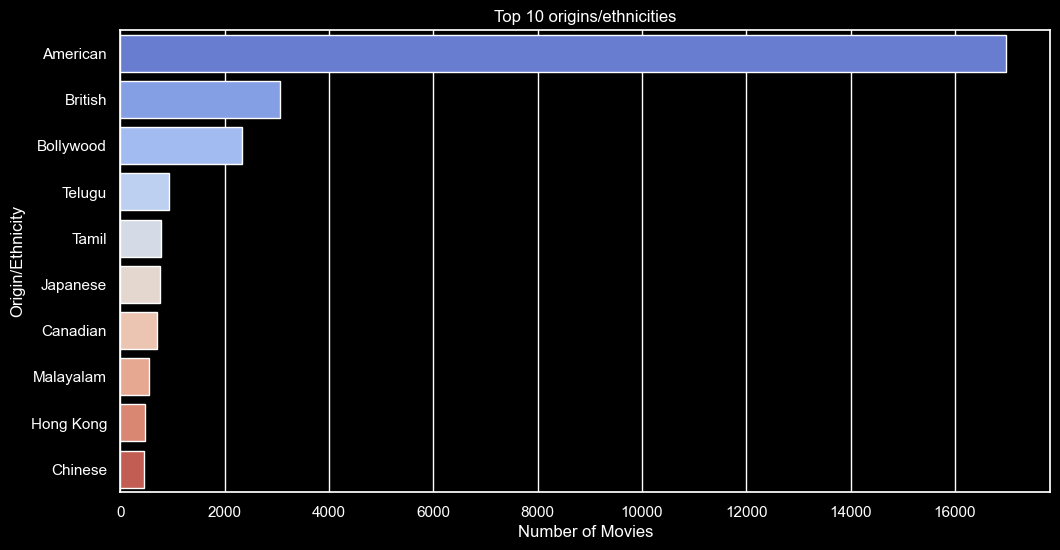

In [8]:
plt.figure(figsize=(12,6))

top_origins = df_clean['Origin/Ethnicity'].value_counts().head(10)

sns.barplot(
    x=top_origins.values,
    y=top_origins.index,
    hue=top_origins.index,
    legend=False,
    palette="coolwarm"
)

plt.title('Top 10 origins/ethnicities')
plt.xlabel('Number of Movies')
plt.show()

### 2.3 Количество фильмов по годам

Линейный график показывает динамику выпуска фильмов по годам. Можно увидеть, в какие периоды киноиндустрия росла особенно активно.

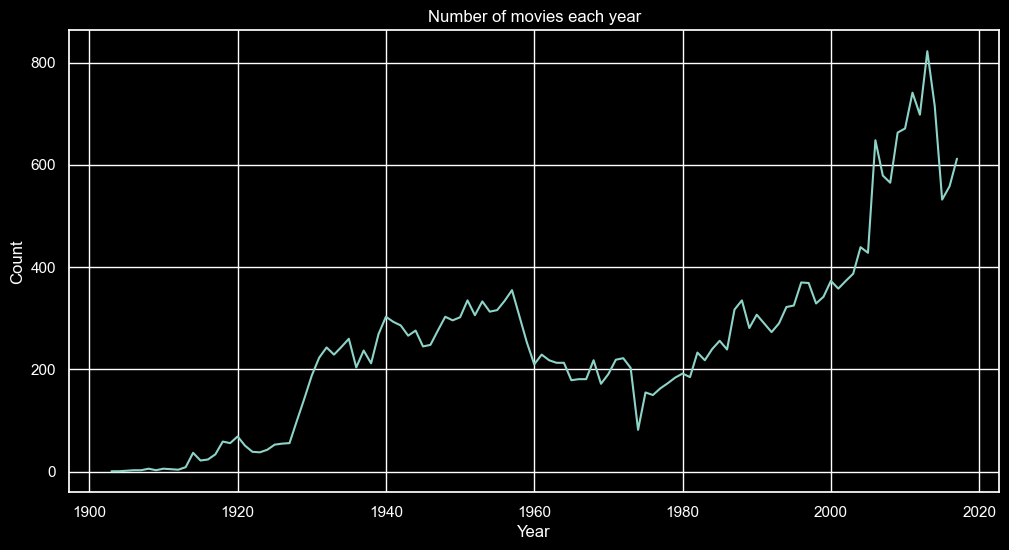

In [10]:
plt.figure(figsize=(12,6))

year_counts = df_clean['Release Year'].value_counts().sort_index()

sns.lineplot(x=year_counts.index, y=year_counts.values)
plt.title('Number of movies each year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

### 2.4 Фильмы по десятилетиям

Группировка по десятилетиям сглаживает шум и даёт более чёткое представление об общей динамике роста производства фильмов.

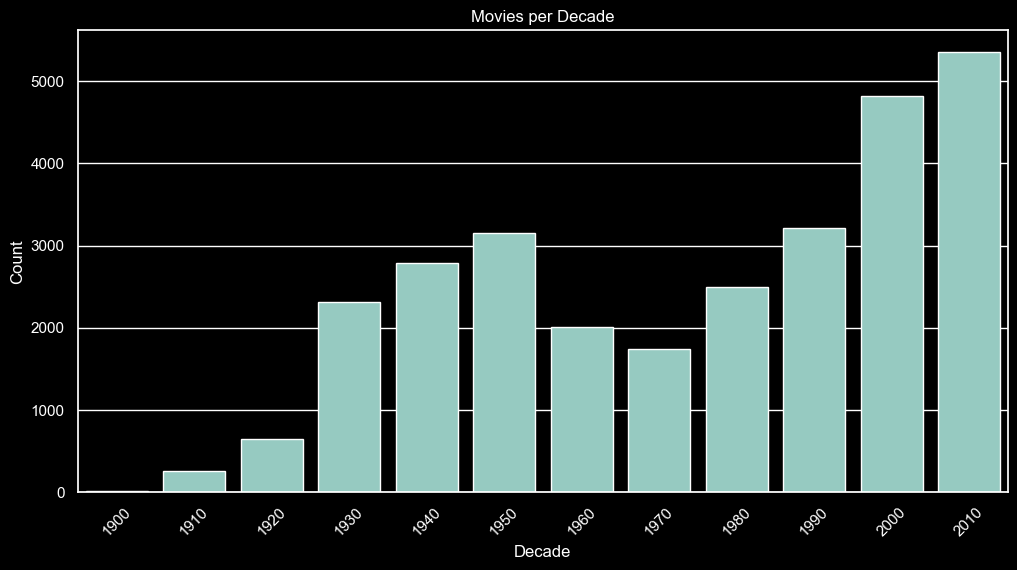

In [12]:
df_clean['Decade'] = (df_clean['Release Year'] // 10) * 10

plt.figure(figsize=(12,6))

decade_counts = df_clean['Decade'].value_counts().sort_index()

sns.barplot(x=decade_counts.index, y=decade_counts.values)
plt.title('Movies per Decade')
plt.xlabel('Decade')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### 2.5 Тренды жанров во времени

Тепловая карта показывает, как менялась популярность топ-5 жанров год от года.

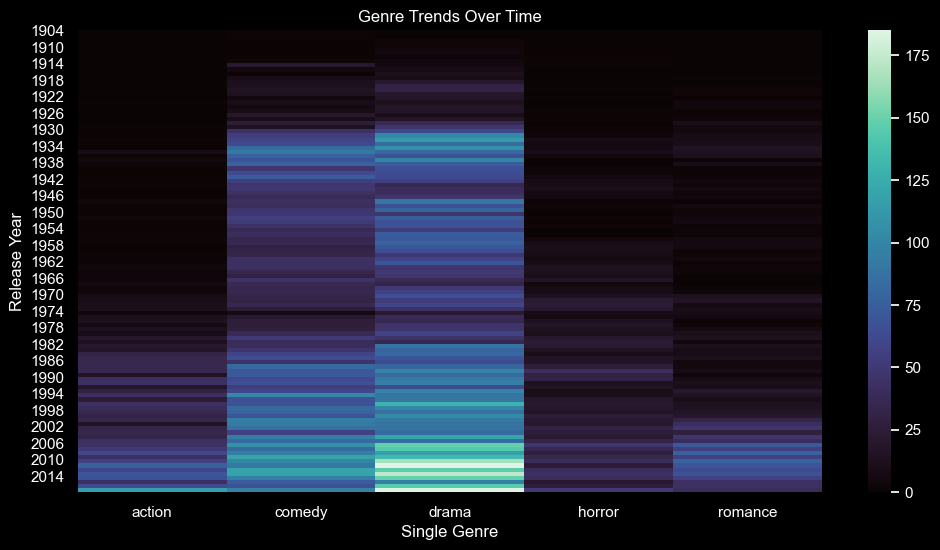

In [14]:
# разбиваем жанры
genres_split = df_clean['Genre'].str.split(', ', expand=True).stack().reset_index(level=1, drop=True)
df_genres = df_clean.copy()
df_genres = df_genres.join(genres_split.rename('Single Genre'))

# берем топ жанры
top_genres = df_genres['Single Genre'].value_counts().head(5).index
df_top = df_genres[df_genres['Single Genre'].isin(top_genres)]

pivot = pd.crosstab(df_top['Release Year'], df_top['Single Genre'])

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='mako')
plt.title('Genre Trends Over Time')
plt.show()

### 2.6 Топ режиссёры по десятилетиям

Смотрим, в каких десятилетиях были наиболее активны пять самых продуктивных режиссёров датасета.

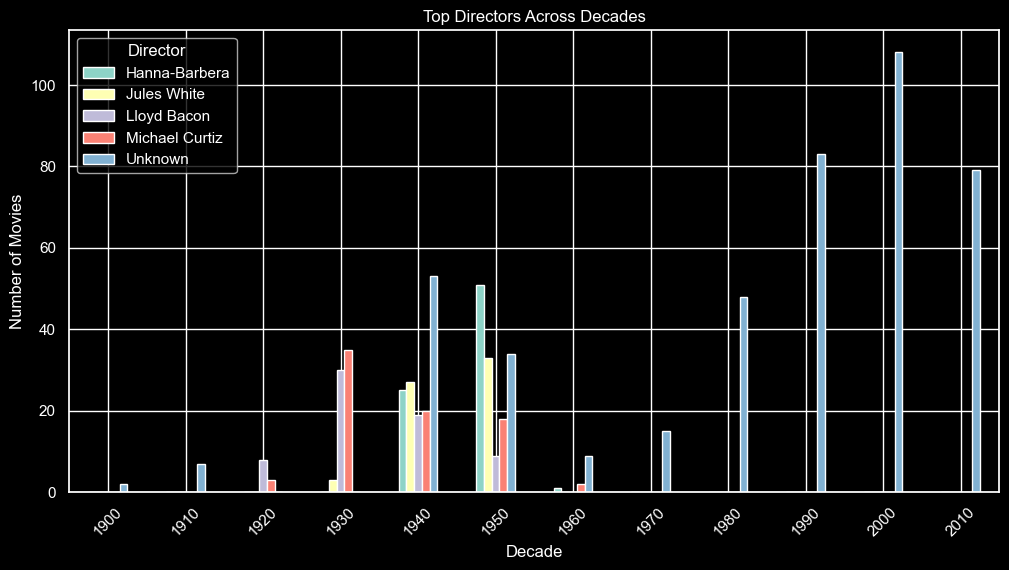

In [16]:
df_clean['Decade'] = (df_clean['Release Year'] // 10) * 10

top_directors = df_clean['Director'].value_counts().head(5).index
df_top = df_clean[df_clean['Director'].isin(top_directors)]

pivot = pd.crosstab(df_top['Decade'], df_top['Director'])

pivot.plot(kind='bar', figsize=(12,6))
plt.title('Top Directors Across Decades')
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()

## 3.0 Metadata sanitization & feature engineering

Подготовка текстовых метаданных для TF-IDF модели.

**Шаги:**

1. **Санитизация** (`smart_sanitize`) - нормализуем строки: убираем пробелы, приводим к нижнему регистру, разделяем множественные значения через `|`.
2. **Soup** - собираем взвешенный текстовый вектор для каждого фильма. Жанр повторяется 4 раза (высокий приоритет), режиссёр 2 раза (средний приоритет), актёры 1 раз.

In [18]:
# define Sanitizer (removes spaces, lowercase)
def smart_sanitize(x):
    text = str(x)
    text = re.sub(r" and ", "|", text)
    text = text.replace("/", "|").replace(",", "|")
    items = text.split("|")
    clean_items = [item.strip().replace(" ", "").lower() for item in items]
    return " ".join(clean_items)

# apply Sanitizer to metadata 
features = ['Genre', 'Cast', 'Director']
for feature in features:
    df_clean[f'{feature}_feature'] = df_clean[feature].apply(smart_sanitize)

# Clean Plot lowercase only
if 'Plot' in df_clean.columns:
    df_clean['Plot_clean'] = df_clean['Plot'].astype(str).str.lower()

# create weighted soup 
# Genre x4(high priority), Director x2(medium priority)
df_clean['soup'] = (
    df_clean['Plot_clean'] + ' ' + 
    df_clean['Genre_feature'] + ' ' + df_clean['Genre_feature'] + ' ' + 
    df_clean['Genre_feature'] + ' ' + df_clean['Genre_feature'] + ' ' + 
    df_clean['Director_feature'] + ' ' + df_clean['Director_feature'] + ' ' +
    df_clean['Cast_feature']
)

print(f"Soup Example: {df_clean['soup'].iloc[0][:100]}...")

Soup Example: the film opens with two bandits breaking into a railroad telegraph office, where they force the oper...


### 3.1 TF-IDF Матрица

Строим разреженную матрицу TF-IDF по полю `soup`. Параметры фильтрации:

- `min_df=5` - игнорируем слова, встречающиеся менее чем в 5 фильмах (шум).
- `max_df=0.7` - игнорируем слова, встречающиеся более чем в 70% фильмов (слишком общие).
- `ngram_range=(1, 2)` - учитываем как отдельные слова, так и биграммы (фразы из 2 слов).

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

# drop duplicates to ensure 1:1 mapping between ID and Title
df_final = df_clean.drop_duplicates(subset='Title', keep='first').reset_index(drop=True)
print(f"Final Unique Movies: {len(df_final)}")

# TF-IDF Matrix
# min_df=5 (Ignore rare words), max_df=0.7 (Ignore common words), ngram_range=(1,2) (Phrases)
tfidf = TfidfVectorizer(stop_words='english', min_df=5, max_df=0.7, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df_final['soup'])

# Index lookup
indices = pd.Series(df_final.index, index=df_final['Title'])

print("Model built and aligned successfully.")

Final Unique Movies: 27084
Model built and aligned successfully.


### 3.2 Функция рекомендаций

Функция `get_recommendations` вычисляет косинусное сходство **на лету** (без хранения полной матрицы схожести) и применяет жанровый фильтр: рекомендации должны совпадать с основным жанром исходного фильма. Из топ-50 кандидатов возвращаем 10 наиболее похожих.

In [22]:
def get_recommendations(title):
    try:
        title = title.strip()
        idx = indices[title]
        
        #  determine genre
        source_genre = str(df_final['Genre'].iloc[idx]).lower()
        
        # priority filter tags
        priority_genres = ['action', 'comedy', 'drama', 'horror', 'romance', 
                           'superhero', 'sci-fi', 'animation', 'thriller', 'crime']
        
        required_tag = None
        for genre in priority_genres:
            if genre in source_genre:
                required_tag = genre
                break
        
        # Calculate similarity (On-Demand)
        cosine_sim_vector = linear_kernel(tfidf_matrix[idx], tfidf_matrix)
        sim_scores = list(enumerate(cosine_sim_vector[0]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        
        # filter results
        final_recommendations = []
        for item in sim_scores[1:51]: # Check top 50 matches
            movie_idx = item[0]
            target_genre = str(df_final['Genre'].iloc[movie_idx]).lower()
            
            # genre rule
            if required_tag and required_tag not in target_genre:
                continue
            
            final_recommendations.append(movie_idx)
            if len(final_recommendations) >= 10:
                break
        
        return df_final[['Title', 'Genre']].iloc[final_recommendations]

    except KeyError:
        return f"Movie '{title}' not found."

# rest
print(get_recommendations('The Lord of the Rings'))

                                                   Title  \
12946  The Lord of the Rings: The Fellowship of the Ring   
13332      The Lord of the Rings: The Return of the King   
13134              The Lord of the Rings: The Two Towers   
9106                              The Return of the King   
15438  Hobbit: The Desolation of Smaug, TheThe Hobbit...   
15952                                           Warcraft   
26651                      Kingsglaive: Final Fantasy XV   
21044                         Four Sisters and a Wedding   
23514                                Jab Harry Met Sejal   
23115                                              Udaan   

                                                   Genre  
12946                                            fantasy  
13332                                 adventure, fantasy  
13134                                 adventure, fantasy  
9106                                           animation  
15438                                 advent

## 4.0 Экспорт модели

Сохраняем всё необходимое для продакшн-использования:

- **`movies.db`** (SQLite) - очищенные метаданные фильмов для UI веб-приложения.
- **`tfidf_matrix.pkl`** - обученная TF-IDF матрица.
- **`indices.pkl`** - маппинг `Title → index` для быстрого поиска фильма.

In [24]:
import sqlite3
import pickle

# save cleaned data to SQL (for the website UI)
conn = sqlite3.connect('movies.db')
db_columns = ['Title', 'Genre', 'Director', 'Cast', 'Plot']
# ensure columns exist
safe_columns = [col for col in db_columns if col in df_final.columns]

# write to SQL
df_final[safe_columns].to_sql('movies', conn, if_exists='replace', index=False)
conn.close()
print("Saved to SQL (movies.db)")

# save model and indices (for the Logic)
with open('tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_matrix, f)

with open('indices.pkl', 'wb') as f:
    pickle.dump(indices, f)

print("Saved Pickles (tfidf_matrix.pkl, indices.pkl)")

Saved to SQL (movies.db)
Saved Pickles (tfidf_matrix.pkl, indices.pkl)


### 4.1 Финальный тест

Проверяем, что модель корректно работает после всего пайплайна.

In [40]:
# test ONE MORE TIME
print(get_recommendations('The Lord of the Rings'))

                                                   Title  \
12946  The Lord of the Rings: The Fellowship of the Ring   
13332      The Lord of the Rings: The Return of the King   
13134              The Lord of the Rings: The Two Towers   
9106                              The Return of the King   
15438  Hobbit: The Desolation of Smaug, TheThe Hobbit...   
15952                                           Warcraft   
26651                      Kingsglaive: Final Fantasy XV   
21044                         Four Sisters and a Wedding   
23514                                Jab Harry Met Sejal   
23115                                              Udaan   

                                                   Genre  
12946                                            fantasy  
13332                                 adventure, fantasy  
13134                                 adventure, fantasy  
9106                                           animation  
15438                                 advent